In [2]:
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
from tensorflow.keras.optimizers import Adam
import keras
from keras.models import Sequential, Model
from keras.layers import *
from keras.utils import Sequence
from keras.layers import Conv2D, MaxPooling2D
from qkeras import *

from keras.utils import Sequence
from keras.callbacks import CSVLogger
from keras.callbacks import EarlyStopping

import os
import random
from datetime import datetime
import time

import matplotlib.pyplot as plt

pi = 3.14159265359
maxval=1e9
minval=1e-9

ModuleNotFoundError: No module named 'qkeras'

In [ ]:
# # os.chdir('SmartPix/data_generator')
os.chdir('/home/harshul-cern/harshul/smart-pixels-ml/')
!pwd

In [ ]:
from DG.OptimizedDataGenerator_v2 import OptimizedDataGenerator
from losses.loss import custom_loss
from models.SoftQuantizeLayer import SoftQuantizeLayer
from models.AnnealingScheduler import AnnealingScheduler
from models.models import CreateModel # Conv2D model

In [ ]:
import keras
from keras.layers import *
from keras.models import Sequential, Model
from keras.utils import Sequence
from qkeras import *

import tensorflow as tf
from tensorflow.keras import datasets, layers, models

def var_network(var, hidden=10, output=2):
    var = Flatten()(var)
    var = QDense(
        hidden,
        kernel_quantizer=quantized_bits(8, 0, alpha=1),
        bias_quantizer=quantized_bits(8, 0, alpha=1),
        kernel_regularizer=tf.keras.regularizers.L1L2(0.01),
        activity_regularizer=tf.keras.regularizers.L2(0.01),
    )(var)
    var = QActivation("quantized_tanh(8, 0, 1)")(var)
    var = QDense(
        hidden,
        kernel_quantizer=quantized_bits(8, 0, alpha=1),
        bias_quantizer=quantized_bits(8, 0, alpha=1),
        kernel_regularizer=tf.keras.regularizers.L1L2(0.01),
        activity_regularizer=tf.keras.regularizers.L2(0.01),
    )(var)
    var = QActivation("quantized_tanh(8, 0, 1)")(var)
    return QDense(
        output,
        kernel_quantizer=quantized_bits(8, 0, alpha=1),
        bias_quantizer=quantized_bits(8, 0, alpha=1),
        kernel_regularizer=tf.keras.regularizers.L1L2(0.01),
    )(var)

def conv_network(var, n_filters=5, kernel_size=3):
    var = QSeparableConv2D(
        n_filters,kernel_size,
        depthwise_quantizer=quantized_bits(4, 0, 1, alpha=1),
        pointwise_quantizer=quantized_bits(4, 0, 1, alpha=1),
        bias_quantizer=quantized_bits(4, 0, alpha=1),
        depthwise_regularizer=tf.keras.regularizers.L1L2(0.01),
        pointwise_regularizer=tf.keras.regularizers.L1L2(0.01),
        activity_regularizer=tf.keras.regularizers.L2(0.01),
    )(var)
    var = QActivation("quantized_tanh(4, 0, 1)")(var)
    var = QConv2D(
        n_filters,1,
        kernel_quantizer=quantized_bits(4, 0, alpha=1),
        bias_quantizer=quantized_bits(4, 0, alpha=1),
        kernel_regularizer=tf.keras.regularizers.L1L2(0.01),
        activity_regularizer=tf.keras.regularizers.L2(0.01),
    )(var)
    var = QActivation("quantized_tanh(4, 0, 1)")(var)    
    return var

def CreateModel(shape, output, n_filters, pool_size):
    x_base = x_in = Input(shape)
    x_base = SoftQuantizeLayer(
        n_bits=2,                     
        initial_range=[-1.0, 1.0],    
        trainable_levels=False,        
        trainable_thresholds=True,          
        initial_k=1.0,                
        trainable_k=True,             
        name='soft_quantizer_output'  
    )(x_base)

    stack = conv_network(x_base)
    stack = AveragePooling2D(
        pool_size=(pool_size, pool_size), 
        strides=None, 
        padding="valid", 
        data_format=None,        
    )(stack)
    stack = QActivation("quantized_bits(8, 0, alpha=1)")(stack)
    stack = var_network(stack, hidden=16, output=output)
    model = Model(inputs=x_in, outputs=stack)
    return model

In [ ]:
os.listdir('/work/projects/SmartPixML/dataset_3srb_16x16_50x12P5_centeredIncidence_10ps_300k_convolved_to_200ps/')

In [9]:
# dataset_base_dir = "/depot/cms/users/das214/datasets/dataset_3sr/dataset_3sr_16x16_50x12P5_parquets/contained"
dataset_base_dir = '/work/projects/SmartPixML/dataset_3s_10ps_50x12P5/'
tfrecords_base_dir = os.path.join(dataset_base_dir, "TFR_files", "2t")

dataset_train_dir = os.path.join(dataset_base_dir, "train")
dataset_test_dir = os.path.join(dataset_base_dir, "test")
tfrecords_dir_train = os.path.join(tfrecords_base_dir, "TFR_train")
tfrecords_dir_val   = os.path.join(tfrecords_base_dir, "TFR_val")

batch_size = 5000
val_batch_size = 5000
train_file_size = len(os.listdir(dataset_train_dir))
val_file_size = len(os.listdir(dataset_test_dir))

In [10]:
val_file_size

20

In [11]:
start_time = time.time()
validation_generator = OptimizedDataGenerator(
    dataset_base_dir = dataset_test_dir,
    file_type = "parquet",
    data_format = "3D",
    batch_size = val_batch_size,
    # optimize_batch_size = True,
    file_count = val_file_size,
    to_standardize= True,
    labels_list = ['x-midplane','y-midplane','cotAlpha','cotBeta'],
    input_shape = (2,13,21), # (20,13,21),
    transpose = (0,2,3,1),
    shuffle = False, 
    files_from_end=True,

    tfrecords_dir = tfrecords_dir_val,
    use_time_stamps = [0,399],
    max_workers = 2
)

print("--- Validation generator %s seconds ---" % (time.time() - start_time))

# training generator
start_time = time.time()
training_generator = OptimizedDataGenerator(
    dataset_base_dir = dataset_train_dir,
    file_type = "parquet",
    data_format = "3D",
    batch_size = batch_size,
    # optimize_batch_size = True,
    file_count = train_file_size,
    to_standardize= True,
    labels_list = ['x-midplane','y-midplane','cotAlpha','cotBeta'],
    input_shape = (2,13,21), # (20,13,21),
    transpose = (0,2,3,1),
    shuffle = False, # True 

    tfrecords_dir = tfrecords_dir_train,
    use_time_stamps = [0, 399],
    max_workers = 2
)
print("--- Training generator %s seconds ---" % (time.time() - start_time))

Processing Files...: 100%|██████████| 20/20 [00:33<00:00,  1.70s/it]


Directory /work/projects/SmartPixML/dataset_3s_10ps_50x12P5/TFR_files/2t/TFR_val is removed...


Saving batches as TFRecords: 100%|██████████| 16/16 [01:04<00:00,  4.03s/it]


Metadata saved successfully ast /work/projects/SmartPixML/dataset_3s_10ps_50x12P5/TFR_files/2t/TFR_val/metadata.json
Loading metadata from /work/projects/SmartPixML/dataset_3s_10ps_50x12P5/TFR_files/2t/TFR_val/metadata.json
--- Validation generator 98.92037391662598 seconds ---


Processing Files...: 100%|██████████| 80/80 [02:09<00:00,  1.62s/it]


Directory /work/projects/SmartPixML/dataset_3s_10ps_50x12P5/TFR_files/2t/TFR_train is removed...


Saving batches as TFRecords: 100%|██████████| 64/64 [04:10<00:00,  3.91s/it]


Metadata saved successfully ast /work/projects/SmartPixML/dataset_3s_10ps_50x12P5/TFR_files/2t/TFR_train/metadata.json
Loading metadata from /work/projects/SmartPixML/dataset_3s_10ps_50x12P5/TFR_files/2t/TFR_train/metadata.json
--- Training generator 380.2010860443115 seconds ---


In [12]:
# Loading pre-generated TFRecords
validation_generator = OptimizedDataGenerator(
    load_from_tfrecords_dir= tfrecords_dir_val,
    shuffle=True,
    seed=42,
    quantize=False,
)

training_generator = OptimizedDataGenerator(
    load_from_tfrecords_dir = tfrecords_dir_train,
    shuffle=True,
    seed=42,
    quantize=False,
)


Loading metadata from /work/projects/SmartPixML/dataset_3s_10ps_50x12P5/TFR_files/2t/TFR_val/metadata.json


Loading metadata from /work/projects/SmartPixML/dataset_3s_10ps_50x12P5/TFR_files/2t/TFR_train/metadata.json


In [13]:
from models.models import CreateModel
model=CreateModel(shape = (13,21,2), output = 14, n_filters=5,pool_size=3)
model.compile(
    optimizer=tf.keras.optimizers.Nadam(learning_rate=1e-3, clipnorm=1.0),
    loss=custom_loss,
)

model.summary()

2025-12-03 00:37:50.871948: I external/local_tsl/tsl/platform/default/subprocess.cc:304] Start cannot spawn child process: No such file or directory


Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 13, 21, 2)]       0         
                                                                 
 q_separable_conv2d (QSepar  (None, 11, 19, 5)         33        
 ableConv2D)                                                     
                                                                 
 q_activation (QActivation)  (None, 11, 19, 5)         0         
                                                                 
 q_conv2d (QConv2D)          (None, 11, 19, 5)         30        
                                                                 
 q_activation_1 (QActivatio  (None, 11, 19, 5)         0         
 n)                                                              
                                                                 
 average_pooling2d (Average  (None, 3, 6, 5)           0     

In [14]:
from datetime import datetime

fingerprint = '%08x' % random.randrange(16**8)
timestamp = datetime.now().strftime('%Y%m%d-%H%M%S')
os.makedirs("trained_models", exist_ok=True)
base_dir = f'./trained_models/model-{fingerprint}-checkpoints'

checkpoints_dir = os.path.join(base_dir, 'checkpoints')

os.makedirs(base_dir, exist_ok=True)
os.makedirs(checkpoints_dir, exist_ok=True) 
checkpoint_filepath = os.path.join(checkpoints_dir, 'weights.{epoch:02d}-t{loss:.2f}-v{val_loss:.2f}.hdf5')

In [15]:
checkpoint_filepath

'./trained_models/model-c2b6dd60-checkpoints/checkpoints/weights.{epoch:02d}-t{loss:.2f}-v{val_loss:.2f}.hdf5'

In [16]:
# 9f5e5c2c : 1000 epochs
print(fingerprint)

c2b6dd60


In [17]:
from tensorflow.keras.callbacks import CSVLogger, EarlyStopping, ModelCheckpoint, Callback
import csv

early_stopping_patience = 50
es = EarlyStopping(patience=early_stopping_patience, restore_best_weights=True)

mcp = ModelCheckpoint(
        filepath=checkpoint_filepath,
        save_weights_only=True,
       save_freq='epoch'
)

class SoftQuantizeLoggerCallback(Callback):
    def __init__(self, log_filepath, layer_name="soft_quantizer_output"):
        super().__init__()
        self.log_filepath = log_filepath
        self.layer_name = layer_name
        self.header_written = False

    def on_train_begin(self, logs=None):
        os.makedirs(os.path.dirname(self.log_filepath), exist_ok=True)

    def on_epoch_end(self, epoch, logs=None):
        try:
            layer = self.model.get_layer(self.layer_name)
            if not hasattr(layer, 'n_bits'):
                 print(f"\nWarning: Layer '{self.layer_name}' is not a SoftQuantizeLayer. Skipping logging.")
                 return
        except ValueError:
            print(f"\nWarning: Layer '{self.layer_name}' not found in the model. Skipping logging.")
            return

        if not self.header_written:
            num_levels = layer.num_levels
            num_thresholds = num_levels - 1
            
            header = ['epoch', 'k']
            header.extend([f'level_{i}' for i in range(num_levels)])
            header.extend([f'threshold_{i}' for i in range(num_thresholds)])

            header.append('raw_first_level')
            header.extend([f'raw_log_level_delta_{i}' for i in range(num_levels - 1)])
            header.append('raw_first_threshold')
            if hasattr(layer, 'log_threshold_deltas'):
                header.extend([f'raw_log_threshold_delta_{i}' for i in range(num_thresholds - 1)])

            with open(self.log_filepath, mode='w', newline='') as f:
                writer = csv.writer(f)
                writer.writerow(header)
            self.header_written = True

        k_val = layer.k.numpy().item()
        levels = layer.levels.numpy().tolist()
        thresholds = layer.thresholds.numpy().tolist()
        
        first_level = layer.first_level.numpy().item()
        log_level_deltas = layer.log_level_deltas.numpy().tolist()
        first_threshold = layer.first_threshold.numpy().item()
        
        row_data = [epoch, k_val]
        row_data.extend(levels)
        row_data.extend(thresholds)
        row_data.append(first_level)
        row_data.extend(log_level_deltas)
        row_data.append(first_threshold)
        
        if hasattr(layer, 'log_threshold_deltas'):
            log_threshold_deltas = layer.log_threshold_deltas.numpy().tolist()
            row_data.extend(log_threshold_deltas)
        
        with open(self.log_filepath, mode='a', newline='') as f:
            writer = csv.writer(f)
            writer.writerow(row_data)


csv_logger = CSVLogger(f'{base_dir}/training_log.csv', append=True)
scheduler_callback = AnnealingScheduler(
    schedule='cosine',  
    target_layer_name='soft_quantizer_output', 
    initial_k=1.0,
    final_k=67.0, 
    verbose=1      
)

quantizer_logger = SoftQuantizeLoggerCallback(
    log_filepath=f"{base_dir}/soft_quantizer_state_log.csv", # New, more descriptive filename
    layer_name="soft_quantizer_output"
)


In [18]:
history = model.fit(
        x=training_generator,
        validation_data=validation_generator,
        # callbacks=[mcp, csv_logger, scheduler_callback, quantizer_logger],
        callbacks=[mcp, csv_logger],
        epochs=1000,
        shuffle=False,
        verbose=1
    )

Epoch 1/1000


2025-12-03 00:39:42.268759: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:454] Loaded cuDNN version 8907
2025-12-03 00:39:42.912880: I external/local_tsl/tsl/platform/default/subprocess.cc:304] Start cannot spawn child process: No such file or directory
2025-12-03 00:39:43.841411: I tensorflow/core/util/cuda_solvers.cc:179] Creating GpuSolver handles for stream 0x55dc6490b4e0
2025-12-03 00:39:46.738989: I external/local_xla/xla/service/service.cc:168] XLA service 0x7ef1ee60f560 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2025-12-03 00:39:46.739058: I external/local_xla/xla/service/service.cc:176]   StreamExecutor device (0): NVIDIA A100-PCIE-40GB MIG 1g.5gb, Compute Capability 8.0
2025-12-03 00:39:46.763101: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1764718786.905047    2405 device_compiler.h:186] Compiled

64/64 [==============================] - 20s 167ms/step - loss: 81876.2969 - val_loss: 23412.8320
Epoch 2/1000
64/64 [==============================] - 6s 93ms/step - loss: 16039.0781 - val_loss: 11164.7324
Epoch 3/1000
64/64 [==============================] - 7s 103ms/step - loss: 7779.8887 - val_loss: 5552.8462
Epoch 4/1000
64/64 [==============================] - 7s 108ms/step - loss: 3917.4963 - val_loss: 3613.3152
Epoch 5/1000
64/64 [==============================] - 6s 96ms/step - loss: 1753.2585 - val_loss: 382.3022
Epoch 6/1000
64/64 [==============================] - 8s 118ms/step - loss: -409.1402 - val_loss: -1120.6168
Epoch 7/1000
64/64 [==============================] - 7s 107ms/step - loss: -1890.9524 - val_loss: -2463.9265
Epoch 8/1000
64/64 [==============================] - 9s 145ms/step - loss: -3073.5908 - val_loss: -3515.6499
Epoch 9/1000
64/64 [==============================] - 10s 149ms/step - loss: -3962.6465 - val_loss: -4340.6914
Epoch 10/1000
64/64 [==========

In [19]:
print(history.history.keys())
print(history.history['loss'][:5])
print(history.history['val_loss'][:5])


dict_keys(['loss', 'val_loss'])
[81876.296875, 16039.078125, 7779.888671875, 3917.496337890625, 1753.258544921875]
[23412.83203125, 11164.732421875, 5552.84619140625, 3613.315185546875, 382.3021545410156]


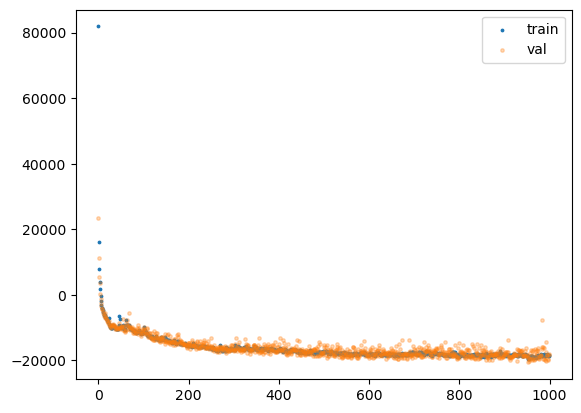

In [20]:
import matplotlib.pyplot as plt

epochs_vals = range(1000)
plt.scatter(epochs_vals, history.history['loss'], label='train', alpha = 1.0, s = 3)
plt.scatter(epochs_vals, history.history['val_loss'], label='val', alpha = 0.3, s = 6)
plt.legend()
plt.show()


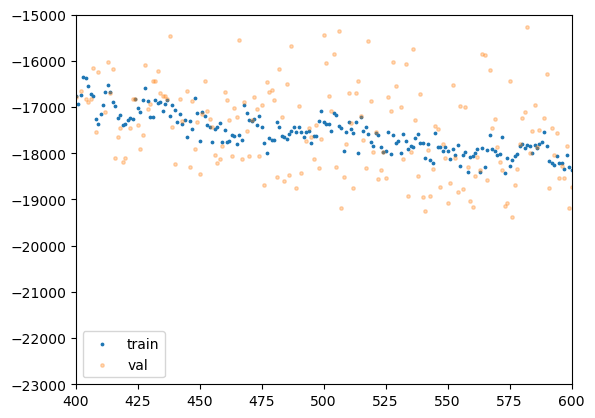

In [21]:
import matplotlib.pyplot as plt

epochs_vals = range(1000)
plt.scatter(epochs_vals, history.history['loss'], label='train', alpha = 1.0, s = 3)
plt.scatter(epochs_vals, history.history['val_loss'], label='val', alpha = 0.3, s = 6)
plt.legend()
plt.xlim([400, 600])
plt.ylim([-23_000, -15_000])
plt.show()
